In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
df = pd.read_csv("/Users/aleksandrsolodovcenko/Downloads/S02-hw-dataset.csv")
df


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [128]:
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [130]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [131]:
missing_data = df.isna().mean()
print(missing_data)

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64


In [132]:
has_duplicates = df.duplicated().any()
print(f"Есть дублирующие строки: {has_duplicates}")

duplicates = df[df.duplicated()]
print(f"\nДублирующие строки:\n{duplicates}")



Есть дублирующие строки: True

Дублирующие строки:
    user_id   age country  purchases  revenue
40       10  24.0      RU          7      511


In [133]:
wrong_data_mask = ((df["age"] < 0) | (df.age > 100) | (df["age"].isna()) | (df["purchases"] < 0) | (df["purchases"].isna()) | (df["revenue"] < 0) | (df["revenue"].isna()) | (df["age"] < 18) | ((df["purchases"] != 0) & (df["revenue"] == 0)))
wrong_data_rows = df[wrong_data_mask]
wrong_data_rows # получаем строки, где значения некорректны

,user_id,age,country,purchases,revenue
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
10,11,24.0,US,4,0
12,13,NaN,US,9,630
20,21,5.0,RU,8,1488


In [134]:
wrong_ind = wrong_data_rows.index 
#получаю индексы строк с неверными данными 

В ходе анализа датасета были выявлены следующие ошибки в данных:

1) Пропущенные значения возрастов 
2) Возраст до 18 лет (неплатежеспособный клиент)
3) Возраст от 120 лет

4) Отрицательное число платежей
5) Нулевая выручка при ненулевом количестве платежей

In [135]:
df = df.drop(wrong_ind).reset_index(drop=True) #очищаем данные путем удаления некорректных
df


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,7,46.0,RU,0,0
5,8,28.0,CN,2,456
6,9,39.0,US,4,980
7,10,24.0,RU,7,511
8,12,20.0,CN,7,1652
9,14,36.0,DE,9,2358


In [136]:
country_counts = df["country"].value_counts()
country_counts

country
RU    12
FR    11
US     6
DE     5
CN     2
Name: count, dtype: int64

In [137]:
def dollars_to_rubbles(n):
    return n * 78

res = df.revenue.agg([dollars_to_rubbles])
res

/var/folders/fx/93vyjwvn6f5cltll8hbp90ww0000gn/T/ipykernel_57177/2346215051.py:4: FutureWarning: using <function dollars_to_rubbles at 0x125dfd040> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  res = df.revenue.agg([dollars_to_rubbles])


,dollars_to_rubbles
0,58422
1,86970
2,31122
3,51012
4,0
5,35568
6,76440
7,39858
8,128856
9,183924


In [138]:
group = df.groupby('country')
group.size()

country
CN     2
DE     5
FR    11
RU    12
US     6
dtype: int64

In [139]:
df.count()

user_id      36
age          36
country      36
purchases    36
revenue      36
dtype: int64

In [140]:
group.count() # число раз, когда значение группы встречалось
# может быть меньше, чем число строк, если значение было пропущено в файле
# тк мы обработали файл, то число число значений одинаково в каждой строке

,user_id,age,purchases,revenue
country,,,,
CN,2,2,2,2
DE,5,5,5,5
FR,11,11,11,11
RU,12,12,12,12
US,6,6,6,6


In [141]:
result = df.groupby('country').agg({
    'user_id': 'count',                    # Количество клиентов
    'purchases': ['sum', 'mean'],         # Сумма и среднее покупок
    'revenue': ['sum', 'mean'],           # Сумма и среднее выручки
    'age': 'mean'                         # Средний возраст
})

result

user_id purchases           revenue                     age
          count       sum      mean     sum         mean       mean
country                                                            
CN            2         9  4.500000    2108  1054.000000  24.000000
DE            5        33  6.600000    7377  1475.400000  34.600000
FR           11        52  4.727273    7326   666.000000  39.545455
RU           12        54  4.500000    8783   731.916667  32.166667
US            6        24  4.000000    3829   638.166667  38.833333

In [142]:
df["age"].mean()

np.float64(35.416666666666664)

Средний возраст покупателей - 35 лет
Больше всего юзеров - в РФ и Франции
Лидируют по выручке - РФ и Германия
Наибольшая средняя выручка в Китае по причине всего 1го клиента, на 2 месте Германия с 5 пользователями

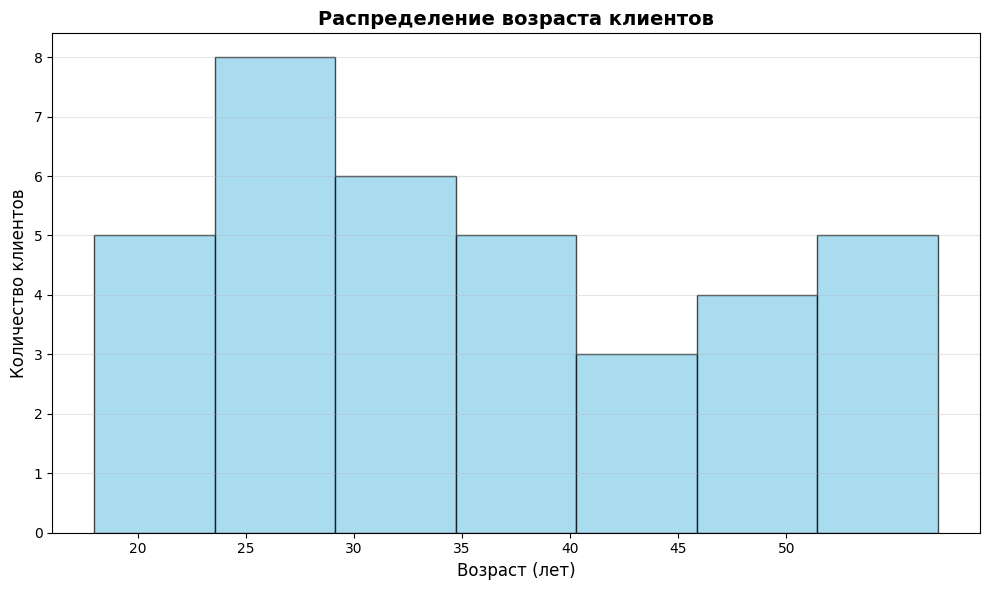

Всего клиентов: 36
Выбрано корзин: 7
Диапазон возраста: от 18.0 до 57.0 лет
Средний возраст: 35.4 лет


In [143]:
# Создаем фигуру
plt.figure(figsize=(10, 6))

# Гистограмма для возраста
# Автоматический выбор числа корзин по правилу Стёрджеса 
n = len(df['age'])
bins_sturges = int(np.ceil(np.log2(n)) + 1)  # Правило Стёрджеса



# Строим гистограмму с выбранным числом корзин
plt.hist(df['age'], bins=bins_sturges, color='skyblue', edgecolor='black', alpha=0.7)

# Настройки графика
plt.title('Распределение возраста клиентов', fontsize=14, fontweight='bold')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Добавляем сетку и улучшаем читаемость
plt.xticks(range(20, 55, 5))  # Метки каждые 5 лет
plt.tight_layout()

plt.show()

print(f"Всего клиентов: {n}")
print(f"Выбрано корзин: {bins_sturges}")
print(f"Диапазон возраста: от {df['age'].min()} до {df['age'].max()} лет")
print(f"Средний возраст: {df['age'].mean():.1f} лет")

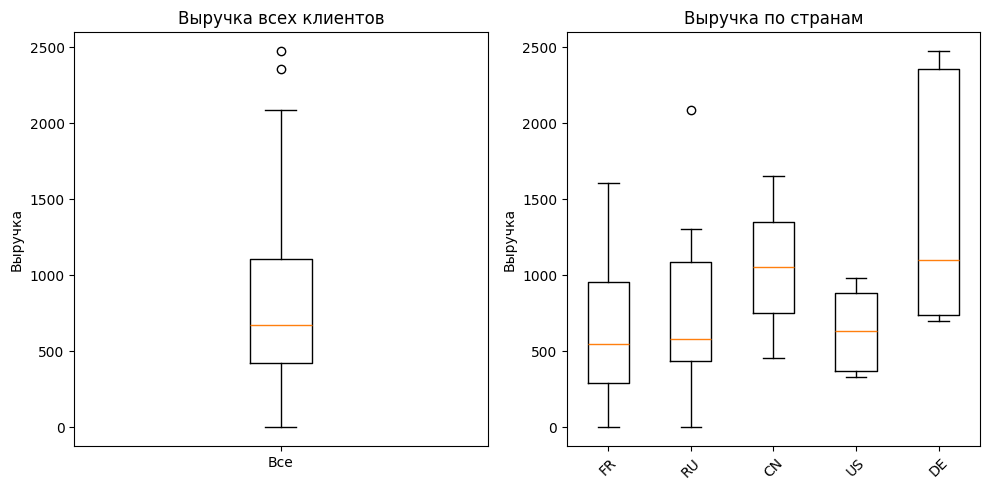

Медиана выручки: 673.5
Средняя выручка: 817.3055555555555


In [144]:
plt.figure(figsize=(10, 5))

# 1. Боксплот для всех данных
plt.subplot(1, 2, 1)
plt.boxplot(df['revenue'])
plt.title('Выручка всех клиентов')
plt.ylabel('Выручка')
plt.xticks([1], ['Все'])

# 2. Боксплот по странам
plt.subplot(1, 2, 2)
# Группируем данные по странам
data = []
labels = []
for country in df['country'].unique():
    data.append(df[df['country'] == country]['revenue'].values)
    labels.append(country)

plt.boxplot(data)
plt.title('Выручка по странам')
plt.ylabel('Выручка')
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)

# Настраиваем отображение
plt.tight_layout()
plt.show()

# Простая статистика
print("Медиана выручки:", df['revenue'].median())
print("Средняя выручка:", df['revenue'].mean())

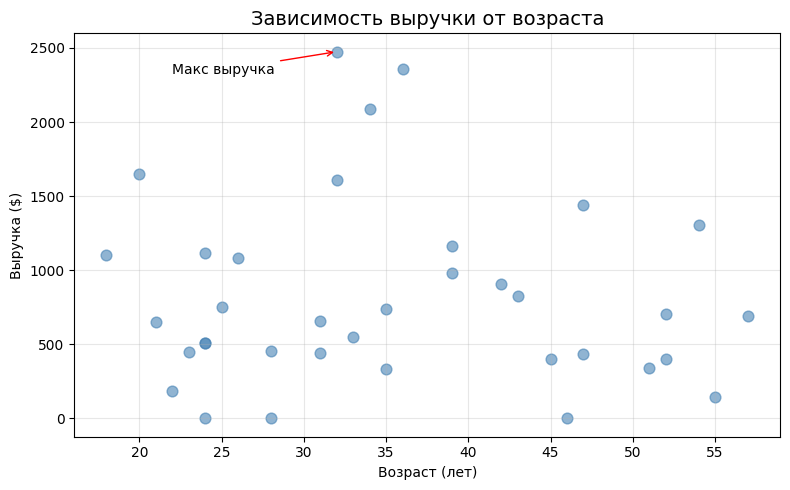

In [145]:
plt.figure(figsize=(8, 5))

plt.scatter(df['age'], df['revenue'], s=60, alpha=0.6, color='steelblue')
plt.title('Зависимость выручки от возраста', fontsize=14)
plt.xlabel('Возраст (лет)')
plt.ylabel('Выручка ($)')
plt.grid(True, alpha=0.3)

max_revenue_row = df[df['revenue'] == df['revenue'].max()]

x_coord = max_revenue_row['age'].values[0]
y_coord = max_revenue_row['revenue'].values[0]

plt.annotate('Макс выручка', xy=(x_coord, y_coord), xytext=(x_coord - 10, y_coord - 150),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()